<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week3_Day2_Exercises_XP_nija.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Exercise 1 : Opérations sur matrice diagonale
# ============================================================

import numpy as np

# Génération d'une matrice 4x4 aléatoire
matrix = np.random.randint(1, 20, size=(4, 4))
print("Matrice originale :")
print(matrix)

# Extraction de la diagonale principale (en haut-gauche → bas-droite)
# np.diag(matrice_2D) retourne le vecteur 1D des éléments diagonaux
diagonal = np.diag(matrix)
print("\nÉléments diagonaux extraits :")
print(diagonal)

# Création d'une matrice diagonale à partir du vecteur
# np.diag(vecteur_1D) retourne une matrice 2D avec ces éléments sur la diagonale
# (et des zéros partout ailleurs)
diag_matrix = np.diag(diagonal)
print("\nMatrice diagonale créée :")
print(diag_matrix)

Matrice originale :
[[13 12  3  5]
 [18 18 16 14]
 [ 7  4  3  2]
 [ 1 14 16 10]]

Éléments diagonaux extraits :
[13 18  3 10]

Matrice diagonale créée :
[[13  0  0  0]
 [ 0 18  0  0]
 [ 0  0  3  0]
 [ 0  0  0 10]]


In [2]:
# ============================================================
# Exercise 2 : Opérations conditionnelles sur tableau
# ============================================================

import numpy as np

# Génération d'un tableau 1D de 20 valeurs entre 0 et 1
arr = np.random.rand(20)
print("Tableau original :")
print(arr.round(2))

# Méthode 1 : boolean masking direct (la plus pythonique)
# Crée un masque True/False puis remplace via indexation booléenne
arr_modified = arr.copy()
arr_modified[arr_modified > 0.5] = -1

print("\nAprès remplacement des valeurs > 0.5 par -1 :")
print(arr_modified.round(2))

# Méthode 2 alternative : np.where (lisible quand on veut 2 cas distincts)
# np.where(condition, valeur_si_vrai, valeur_si_faux)
arr_where = np.where(arr > 0.5, -1, arr)
print("\nMême résultat avec np.where :")
print(arr_where.round(2))

# Vérification
nb_replaced = (arr_modified == -1).sum()
print(f"\n→ {nb_replaced} valeurs remplacées sur 20")

Tableau original :
[0.54 0.63 0.48 0.24 0.17 0.44 0.96 0.57 0.39 0.02 0.85 0.85 0.93 0.24
 0.49 0.9  0.25 0.36 0.05 0.89]

Après remplacement des valeurs > 0.5 par -1 :
[-1.   -1.    0.48  0.24  0.17  0.44 -1.   -1.    0.39  0.02 -1.   -1.
 -1.    0.24  0.49 -1.    0.25  0.36  0.05 -1.  ]

Même résultat avec np.where :
[-1.   -1.    0.48  0.24  0.17  0.44 -1.   -1.    0.39  0.02 -1.   -1.
 -1.    0.24  0.49 -1.    0.25  0.36  0.05 -1.  ]

→ 9 valeurs remplacées sur 20


In [3]:
# ============================================================
# Exercise 3 : Normalisation (Z-score)
# Formule : x_norm = (x - μ) / σ
# ============================================================

import numpy as np
from sklearn.preprocessing import StandardScaler

# Génération d'un tableau 1D
arr = np.random.randint(10, 100, size=15)
print("Tableau original :", arr)

# ── Méthode 1 : calcul manuel (formule directe) ─────────────
mean = arr.mean()       # μ : moyenne
std  = arr.std()        # σ : écart-type
arr_normalized = (arr - mean) / std

print(f"\nMoyenne (μ)   : {mean:.2f}")
print(f"Écart-type (σ): {std:.2f}")
print("\nTableau normalisé (Z-score) :")
print(arr_normalized.round(3))

# Vérification : moyenne ≈ 0 et écart-type ≈ 1 après normalisation
print(f"\n→ Vérification : moyenne = {arr_normalized.mean():.2f}, std = {arr_normalized.std():.2f}")

# ── Méthode 2 : avec sklearn StandardScaler ─────────────────
# StandardScaler attend un tableau 2D, donc reshape(-1, 1)
scaler = StandardScaler()
arr_sklearn = scaler.fit_transform(arr.reshape(-1, 1)).flatten()

print("\nMême résultat avec StandardScaler :")
print(arr_sklearn.round(3))

Tableau original : [77 27 18 46 76 15 58 59 28 60 25 91 80 48 10]

Moyenne (μ)   : 47.87
Écart-type (σ): 25.39

Tableau normalisé (Z-score) :
[ 1.147 -0.822 -1.176 -0.074  1.108 -1.294  0.399  0.438 -0.782  0.478
 -0.901  1.699  1.266  0.005 -1.491]

→ Vérification : moyenne = -0.00, std = 1.00

Même résultat avec StandardScaler :
[ 1.147 -0.822 -1.176 -0.074  1.108 -1.294  0.399  0.438 -0.782  0.478
 -0.901  1.699  1.266  0.005 -1.491]


In [4]:
# ============================================================
# Exercise 4 : Coefficient de corrélation de Pearson
# r ∈ [-1, 1] : -1 = corrélation négative parfaite, +1 = positive parfaite
# ============================================================

import numpy as np

# Deux tableaux de données (par exemple : heures d'étude vs notes)
hours_studied = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
exam_scores   = np.array([50, 55, 65, 70, 75, 80, 82, 88, 92, 95])

# ── Méthode 1 : np.corrcoef → matrice de corrélation 2x2 ────
# La corrélation entre arr1 et arr2 se trouve en [0, 1] ou [1, 0]
corr_matrix = np.corrcoef(hours_studied, exam_scores)
print("Matrice de corrélation :")
print(corr_matrix.round(4))

pearson_r = corr_matrix[0, 1]
print(f"\nCoefficient de Pearson r = {pearson_r:.4f}")

# Interprétation
if pearson_r > 0.7:
    interpretation = "corrélation positive forte"
elif pearson_r > 0.3:
    interpretation = "corrélation positive modérée"
elif pearson_r > -0.3:
    interpretation = "corrélation faible / inexistante"
elif pearson_r > -0.7:
    interpretation = "corrélation négative modérée"
else:
    interpretation = "corrélation négative forte"

print(f"→ Interprétation : {interpretation}")

# ── Méthode 2 (bonus) : avec scipy pour avoir aussi la p-value ──
from scipy import stats
r, p_value = stats.pearsonr(hours_studied, exam_scores)
print(f"\nAvec scipy : r = {r:.4f} | p-value = {p_value:.6f}")
print(f"→ {'Significatif' if p_value < 0.05 else 'Non significatif'} (seuil α = 0.05)")

Matrice de corrélation :
[[1.     0.9894]
 [0.9894 1.    ]]

Coefficient de Pearson r = 0.9894
→ Interprétation : corrélation positive forte

Avec scipy : r = 0.9894 | p-value = 0.000000
→ Significatif (seuil α = 0.05)


Données quotidiennes : [101 142  64 121 110  70 132 136 124 124 137 149  73  52  71]

Équation de la tendance : y = -1.47 × x + 118.84
→ Tendance : baissière (-1.47/jour)


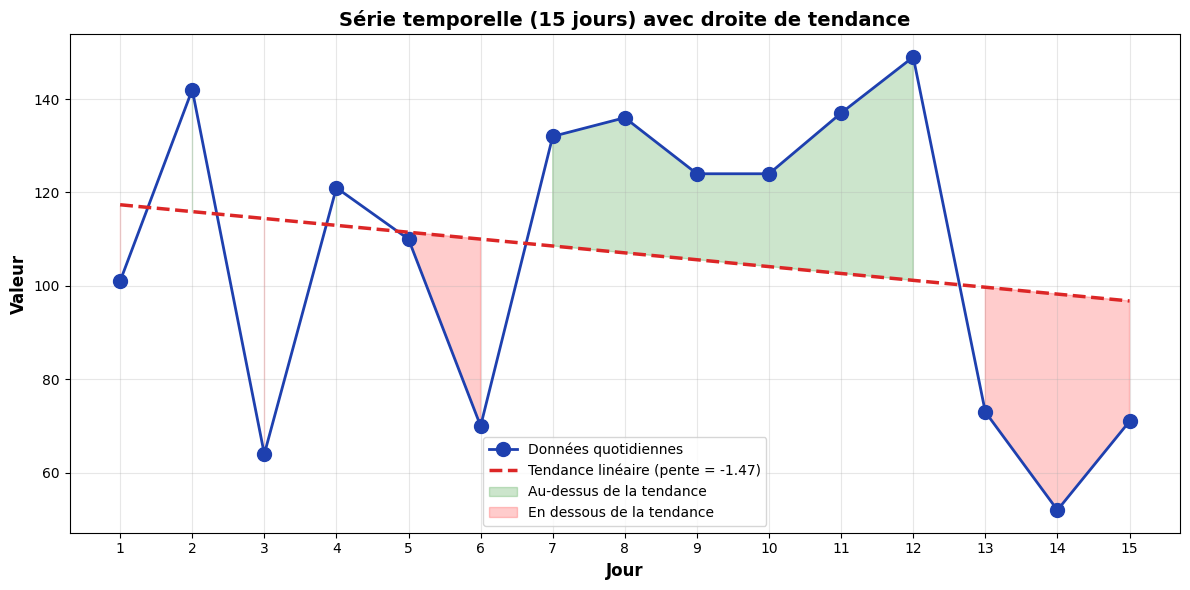

In [5]:
# ============================================================
# Exercise 5 : Time Series + droite de tendance
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Série temporelle de 15 jours avec valeurs aléatoires
np.random.seed(42)
days   = np.arange(1, 16)                            # jours 1 à 15
values = np.random.randint(50, 150, size=15)         # valeurs aléatoires
print("Données quotidiennes :", values)

# Ajustement d'une droite de tendance (régression linéaire degré 1)
# np.polyfit retourne les coefficients [pente, ordonnée à l'origine]
slope, intercept = np.polyfit(days, values, deg=1)
trend_line = slope * days + intercept

print(f"\nÉquation de la tendance : y = {slope:.2f} × x + {intercept:.2f}")
print(f"→ Tendance : {'haussière' if slope > 0 else 'baissière'} ({slope:+.2f}/jour)")

# Visualisation
plt.figure(figsize=(12, 6))

# Série originale
plt.plot(days, values, 'o-', color='#1E40AF', linewidth=2,
         markersize=10, label='Données quotidiennes')

# Droite de tendance
plt.plot(days, trend_line, '--', color='#DC2626', linewidth=2.5,
         label=f'Tendance linéaire (pente = {slope:.2f})')

# Zone d'écart entre données et tendance (résidus visuels)
plt.fill_between(days, values, trend_line,
                 where=(values > trend_line), alpha=0.2, color='green', label='Au-dessus de la tendance')
plt.fill_between(days, values, trend_line,
                 where=(values <= trend_line), alpha=0.2, color='red', label='En dessous de la tendance')

plt.xlabel('Jour', fontweight='bold', fontsize=12)
plt.ylabel('Valeur', fontweight='bold', fontsize=12)
plt.title('Série temporelle (15 jours) avec droite de tendance', fontweight='bold', fontsize=14)
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.xticks(days)
plt.tight_layout()
plt.show()